In [1]:
! pip install pandas numpy matplotlib seaborn scikit-learn xgboost plotly streamlit joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 90.0 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("parking.csv")

In [4]:
df.head()

,SystemCodeNumber,Capacity,Occupancy,LastUpdated
0,BHMBCCMKT01,577,61,2016-10-04 07:59:42
1,BHMBCCMKT01,577,64,2016-10-04 08:25:42
2,BHMBCCMKT01,577,80,2016-10-04 08:59:42
3,BHMBCCMKT01,577,107,2016-10-04 09:32:46
4,BHMBCCMKT01,577,150,2016-10-04 09:59:48


In [5]:
df.shape

(35717, 4)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35717 entries, 0 to 35716
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   SystemCodeNumber  35717 non-null  object
 1   Capacity          35717 non-null  int64 
 2   Occupancy         35717 non-null  int64 
 3   LastUpdated       35717 non-null  object
dtypes: int64(2), object(2)
memory usage: 1.1+ MB


In [7]:
df.describe()

,Capacity,Occupancy
count,35717.000000,35717.000000
mean,1397.550130,642.228911
std,1179.326833,656.955535
min,220.000000,-8.000000
25%,500.000000,210.000000
50%,849.000000,446.000000
75%,2009.000000,798.000000
max,4675.000000,4327.000000


In [8]:
df.columns

Index(['SystemCodeNumber', 'Capacity', 'Occupancy', 'LastUpdated'], dtype='object')

In [9]:
df["SystemCodeNumber"].nunique()

30

In [ ]:
df["SystemCodeNumber"].value_counts()

In [11]:
df["LastUpdated"] = pd.to_datetime(df["LastUpdated"])

In [12]:
df["LastUpdated"].dtype

dtype('<M8[ns]')

In [13]:
# Creating occupanyRate Feature
df["OccupancyRate"] = df["Occupancy"] / df["Capacity"]

In [14]:
df["OccupancyPercent"] = df["OccupancyRate"] * 100

In [15]:
df[[
    "Capacity",
    "Occupancy",
    "OccupancyRate",
    "OccupancyPercent"
]].head()

,Capacity,Occupancy,OccupancyRate,OccupancyPercent
0,577,61,0.105719,10.571924
1,577,64,0.110919,11.091854
2,577,80,0.138648,13.864818
3,577,107,0.185442,18.544194
4,577,150,0.259965,25.996534


In [16]:
# checking parking availability:
# available spaces = capacity - occupancy
df["AvailableSpaces"] = (df["Capacity"] - df["Occupancy"])


In [18]:
# extracting time features
df["Date"] = df["LastUpdated"].dt.date
df["Hour"] = df["LastUpdated"].dt.hour
df["Minute"] = df["LastUpdated"].dt.minute
df["DayOfWeek"] = df["LastUpdated"].dt.dayofweek
df["DayName"] = df["LastUpdated"].dt.day_name()
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)

In [19]:
# creating peak- hour feature
df["IsPeakHour"] = (df["Hour"].between(9, 16)).astype(int)

Data Validation

In [20]:
df.isnull().sum()

,0
SystemCodeNumber,0
Capacity,0
Occupancy,0
LastUpdated,0
OccupancyRate,0
OccupancyPercent,0
AvailableSpaces,0
Date,0
Hour,0
Minute,0


In [21]:
df.duplicated().sum()

np.int64(216)

In [24]:
df = df.drop_duplicates().copy()

In [25]:
df.duplicated().sum()

np.int64(0)

In [22]:
df[df["Occupancy"] < 0]

,SystemCodeNumber,Capacity,Occupancy,LastUpdated,OccupancyRate,OccupancyPercent,AvailableSpaces,Date,Hour,Minute,DayOfWeek,DayName,IsWeekend,IsPeakHour
23889,NIA North,480,-3,2016-10-16 15:57:16,-0.006250,-0.625000,483,2016-10-16,15,57,6,Sunday,1,1
23890,NIA North,480,-3,2016-10-16 16:31:17,-0.006250,-0.625000,483,2016-10-16,16,31,6,Sunday,1,1
23906,NIA North,480,-1,2016-10-18 15:27:59,-0.002083,-0.208333,481,2016-10-18,15,27,1,Tuesday,0,1
23919,NIA North,480,-8,2016-10-28 13:02:43,-0.016667,-1.666667,488,2016-10-28,13,2,4,Friday,0,1
23924,NIA North,480,-1,2016-10-28 15:29:41,-0.002083,-0.208333,481,2016-10-28,15,29,4,Friday,0,1
23925,NIA North,480,-4,2016-10-28 16:02:40,-0.008333,-0.833333,484,2016-10-28,16,2,4,Friday,0,1
23926,NIA North,480,-1,2016-10-28 16:29:42,-0.002083,-0.208333,481,2016-10-28,16,29,4,Friday,0,1
23937,NIA North,480,-2,2016-10-29 12:59:51,-0.004167,-0.416667,482,2016-10-29,12,59,5,Saturday,1,1
23944,NIA North,480,-1,2016-10-29 16:26:53,-0.002083,-0.208333,481,2016-10-29,16,26,5,Saturday,1,1
23997,NIA North,480,-3,2016-11-10 16:00:15,-0.006250,-0.625000,483,2016-11-10,16,0,3,Thursday,0,1


In [26]:
df = df[df["Occupancy"] >= 0].copy()

In [27]:
df[df["Occupancy"] < 0]

,SystemCodeNumber,Capacity,Occupancy,LastUpdated,OccupancyRate,OccupancyPercent,AvailableSpaces,Date,Hour,Minute,DayOfWeek,DayName,IsWeekend,IsPeakHour


In [23]:
df[df["Occupancy"] > df["Capacity"]]

,SystemCodeNumber,Capacity,Occupancy,LastUpdated,OccupancyRate,OccupancyPercent,AvailableSpaces,Date,Hour,Minute,DayOfWeek,DayName,IsWeekend,IsPeakHour
1396,BHMBCCPST01,317,320,2016-10-08 14:03:38,1.009464,100.946372,-3,2016-10-08,14,3,5,Saturday,1,1
1613,BHMBCCPST01,317,318,2016-10-22 14:39:47,1.003155,100.315457,-1,2016-10-22,14,39,5,Saturday,1,1
3548,BHMBCCSNH01,863,865,2016-11-28 11:01:30,1.002317,100.231750,-2,2016-11-28,11,1,0,Monday,0,1
3549,BHMBCCSNH01,863,866,2016-11-28 11:32:28,1.003476,100.347625,-3,2016-11-28,11,32,0,Monday,0,1
3583,BHMBCCSNH01,863,864,2016-11-30 10:28:38,1.001159,100.115875,-1,2016-11-30,10,28,2,Wednesday,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7542,BHMBRCBRG02,1194,1198,2016-12-18 14:03:26,1.003350,100.335008,-4,2016-12-18,14,3,6,Sunday,1,1
12732,BHMMBMMBX01,687,688,2016-12-19 13:03:30,1.001456,100.145560,-1,2016-12-19,13,3,0,Monday,0,1
14796,BHMNCPLDH01,720,723,2016-11-16 11:00:51,1.004167,100.416667,-3,2016-11-16,11,0,2,Wednesday,0,1
15350,BHMNCPNHS01,500,501,2016-10-04 10:26:49,1.002000,100.200000,-1,2016-10-04,10,26,1,Tuesday,0,1


In [28]:
df["Occupancy"] = df["Occupancy"].clip(
    upper=df["Capacity"]
)

In [29]:
df[df["Occupancy"] > df["Capacity"]]

,SystemCodeNumber,Capacity,Occupancy,LastUpdated,OccupancyRate,OccupancyPercent,AvailableSpaces,Date,Hour,Minute,DayOfWeek,DayName,IsWeekend,IsPeakHour


EDA Questions

In [30]:
# Q1 Which parking lots have the highest average utilization?

df.groupby("SystemCodeNumber")["OccupancyPercent"].mean().sort_values(
    ascending=False
)

,OccupancyPercent
SystemCodeNumber,
BHMBRTARC01,77.664498
BHMBCCTHL01,74.695389
BHMNCPNHS01,71.580739
BHMNCPLDH01,70.394332
BHMMBMMBX01,69.577095
BHMBCCSNH01,66.458320
BHMNCPRAN01,64.901476
BHMEURBRD01,64.551008
BHMBRCBRG01,64.391622


In [31]:
# Q2. Which hours have the highest demand?

df.groupby("Hour")["OccupancyPercent"].mean()

,OccupancyPercent
Hour,
7,21.087751
8,25.532723
9,37.198720
10,46.624312
11,54.649539
12,59.062685
13,60.570754
14,60.716759
15,56.218678


In [32]:
# Q3. Weekday vs weekend?

df.groupby("IsWeekend")["OccupancyPercent"].mean()

,OccupancyPercent
IsWeekend,
0,53.215615
1,39.237359


In [33]:
# Q4. Which lots are underutilized?

df.groupby("SystemCodeNumber")["OccupancyPercent"].mean().sort_values()

,OccupancyPercent
SystemCodeNumber,
NIA North,8.149093
NIA Car Parks,16.396813
Others-CCCPS119a,19.320839
BHMNCPPLS01,19.723331
NIA South,24.999894
BHMBCCMKT01,28.159398
BHMBRCBRG03,28.776028
Others-CCCPS98,32.768964
Others-CCCPS202,34.482302


Visualization

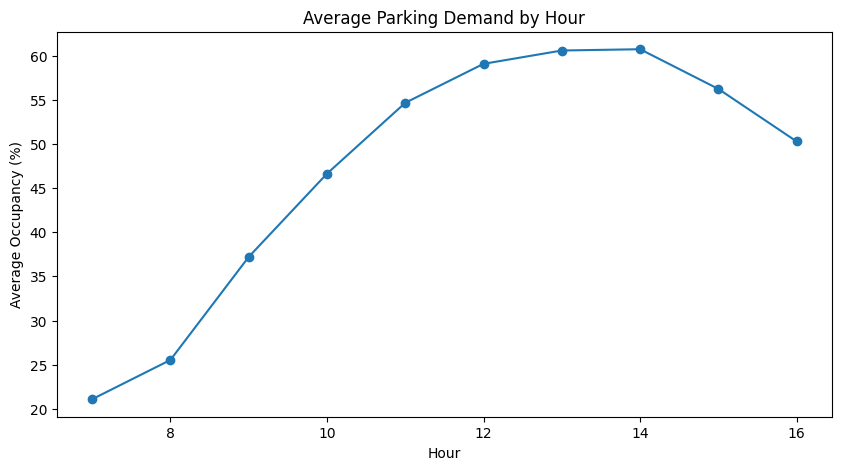

In [34]:
hourly_demand = (
    df.groupby("Hour")["OccupancyPercent"]
      .mean()
)

plt.figure(figsize=(10,5))

plt.plot(
    hourly_demand.index,
    hourly_demand.values,
    marker="o"
)

plt.xlabel("Hour")
plt.ylabel("Average Occupancy (%)")
plt.title("Average Parking Demand by Hour")

plt.show()

In [35]:
df.to_csv("parking_cleaned.csv",index=False)